# Smart Healthcare Diagnostic Hub
## Phase 01: ML Data - Cleaning & Preprocessing
### Diabetes & Heart Disease Dataset Analysis

## 1. Setup & Data Loading

In [ ]:
!pip install opendatasets pandas numpy scikit-learn imbalanced-learn matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset')

Skipping, found downloaded files in "./diabetes-health-indicators-dataset" (use force=True to force download)


### Advanced Feature Selection & Multi-Model Comparison

In [12]:
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

# Prepare data for VIF/ANOVA/Chi-Square
# Using the cleaned dataframe from previous cells
analysis_df = df_clean.copy()
X_select = analysis_df.drop('Diabetes_binary', axis=1)
y_select = analysis_df['Diabetes_binary']

print("--- VIF Test ---")
X_vif = add_constant(X_select)
vif_series = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])], index=X_vif.columns)
print(vif_series)

print("\n--- Chi-Square Feature Scores ---")
best_features = SelectKBest(score_func=chi2, k='all')
fit = best_features.fit(X_select, y_select)
df_scores = pd.DataFrame({'Feature': X_select.columns, 'Score': fit.scores_}).sort_values(by='Score', ascending=False)
display(df_scores)

--- VIF Test ---
const                   108.480338
HighBP                    1.301200
HighChol                  1.158112
CholCheck                 1.035274
BMI                       1.121050
Smoker                    1.076032
Stroke                    1.077470
HeartDiseaseorAttack      1.167062
PhysActivity              1.130509
Fruits                    1.097947
Veggies                   1.098133
HvyAlcoholConsump         1.026354
AnyHealthcare             1.109839
NoDocbcCost               1.135647
GenHlth                   1.716096
MentHlth                  1.221587
PhysHlth                  1.594297
DiffWalk                  1.511628
Sex                       1.075743
Age                       1.353317
Education                 1.272080
Income                    1.430313
dtype: float64

--- Chi-Square Feature Scores ---


,Feature,Score
15,PhysHlth,97988.761672
3,BMI,15507.736174
14,MentHlth,11419.584750
18,Age,8539.906340
0,HighBP,8098.548237
16,DiffWalk,7875.496177
13,GenHlth,7671.732832
6,HeartDiseaseorAttack,5822.145697
1,HighChol,4869.312739
20,Income,3377.099257


In [9]:
df = pd.read_csv('diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (253680, 22)

First few rows:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.

## 2. Data Cleaning & Missing Values

In [10]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

print("Missing Values Analysis:")
print(missing_data[missing_data['Missing_Count'] > 0])

df_clean = df.dropna()
print(f"\nRows removed: {len(df) - len(df_clean)}")
print(f"Clean dataset shape: {df_clean.shape}")

Missing Values Analysis:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []

Rows removed: 0
Clean dataset shape: (253680, 22)


In [11]:
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

df_clean = df_clean.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df_clean.shape}")

Duplicate rows: 24206
Dataset shape after removing duplicates: (229474, 22)


## 3. Exploratory Data Analysis (EDA)

Target variable: Diabetes_binary

Target distribution:
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64

Target distribution (%)
Diabetes_binary
0.0    84.705457
1.0    15.294543
Name: proportion, dtype: float64


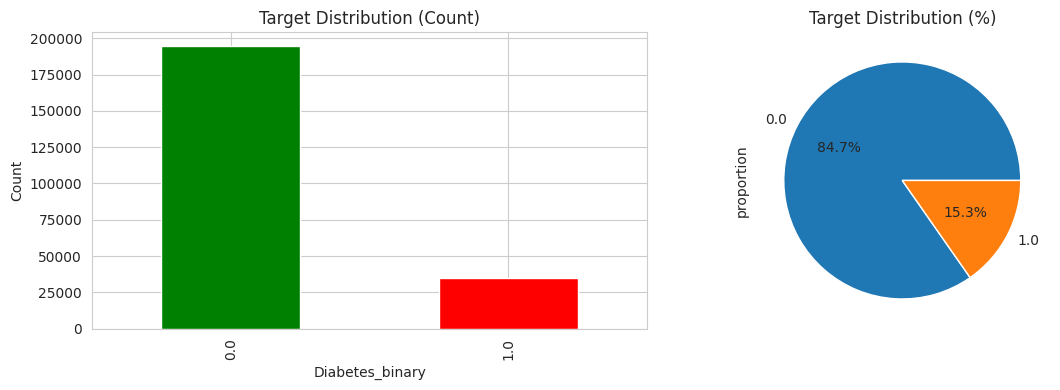

In [13]:
target_col = df_clean.columns[0]
print(f"Target variable: {target_col}")
print(f"\nTarget distribution:")
print(df_clean[target_col].value_counts())
print(f"\nTarget distribution (%)")
print(df_clean[target_col].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Target Distribution (Count)')
axes[0].set_ylabel('Count')

df_clean[target_col].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Target Distribution (%)')
plt.tight_layout()
plt.show()


Top 10 features correlated with Diabetes_binary:
Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
Name: Diabetes_binary, dtype: float64


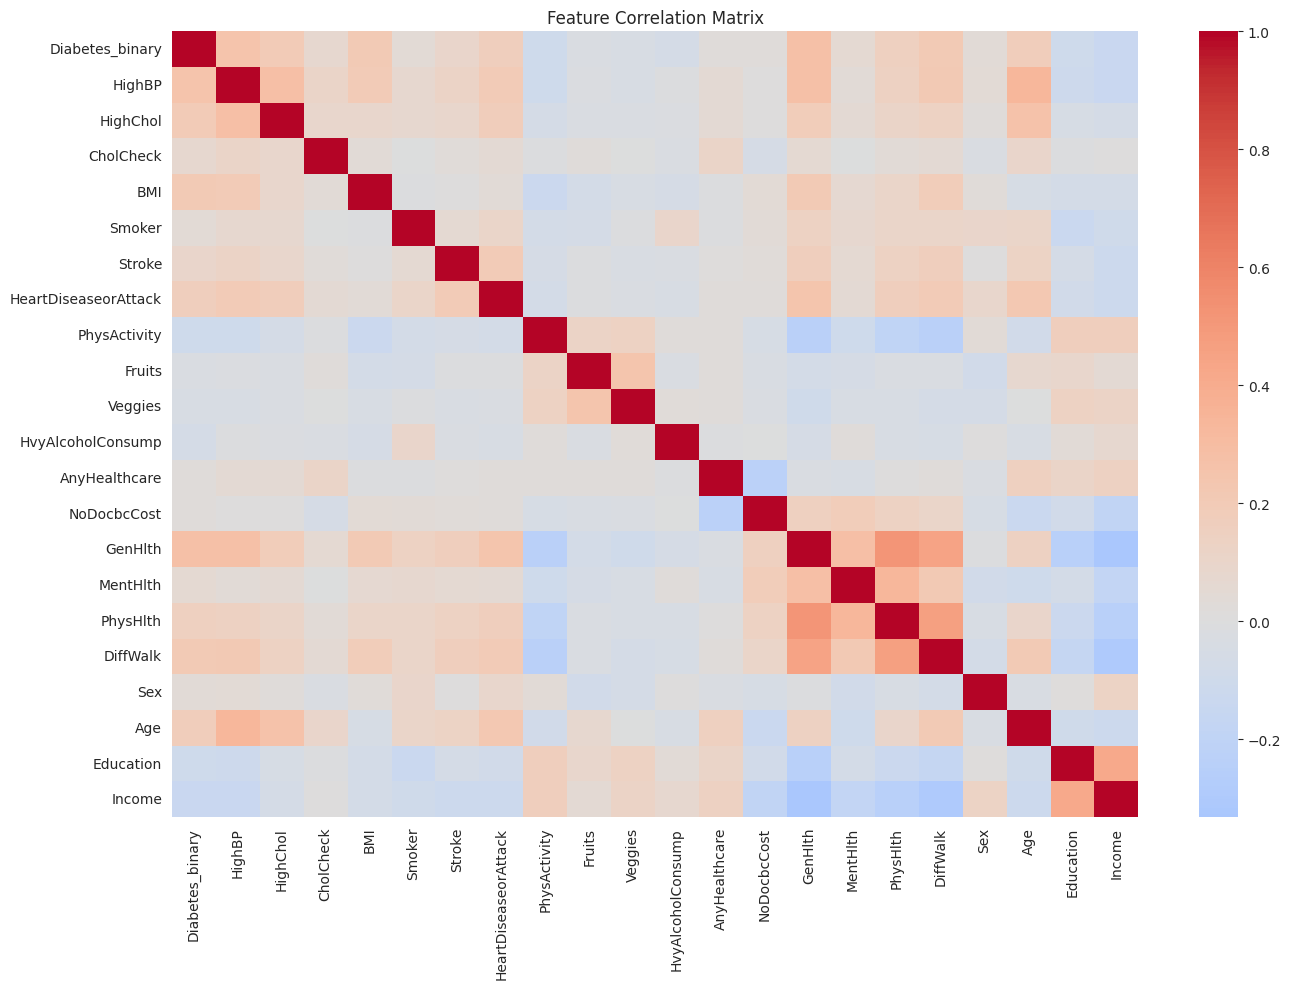

In [14]:
correlation_matrix = df_clean.corr()

target_correlations = correlation_matrix[target_col].sort_values(ascending=False)
print(f"\nTop 10 features correlated with {target_col}:")
print(target_correlations.head(11))  # 11 to exclude target itself

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [15]:
print("Feature Statistics:")
print(df_clean.describe())

def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()

print("\nOutlier Detection (IQR method):")
outlier_counts = {col: detect_outliers(df_clean, col) for col in df_clean.columns}
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier_Count'])
print(outlier_df[outlier_df['Outlier_Count'] > 0].sort_values('Outlier_Count', ascending=False))

Feature Statistics:
       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    229474.000000  229474.000000  229474.000000  229474.000000   
mean          0.152945       0.454343       0.441640       0.959481   
std           0.359936       0.497912       0.496584       0.197173   
min           0.000000       0.000000       0.000000       0.000000   
25%           0.000000       0.000000       0.000000       1.000000   
50%           0.000000       0.000000       0.000000       1.000000   
75%           0.000000       1.000000       1.000000       1.000000   
max           1.000000       1.000000       1.000000       1.000000   

                 BMI        Smoker         Stroke  HeartDiseaseorAttack  \
count  229474.000000  229474.00000  229474.000000         229474.000000   
mean       28.687507       0.46580       0.044816              0.103336   
std         6.789204       0.49883       0.206899              0.304398   
min        12.000000       0.00000      

## 4. Feature Scaling & Preprocessing

In [16]:
x = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(x.columns)}")

Features shape: (229474, 21)
Target shape: (229474,)

Feature columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [17]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

print("Scaled features statistics:")
print(x_scaled.describe())

# Verify scaling
print(f"\nMean (should be ~0): {x_scaled.mean().mean():.6f}")
print(f"Std (should be ~1): {x_scaled.std().mean():.6f}")

Scaled features statistics:
             HighBP      HighChol     CholCheck           BMI        Smoker  \
count  2.294740e+05  2.294740e+05  2.294740e+05  2.294740e+05  2.294740e+05   
mean  -7.527730e-17 -4.735940e-17 -8.917625e-17 -1.622745e-16 -5.737625e-17   
std    1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   
min   -9.124990e-01 -8.893597e-01 -4.866203e+00 -2.457953e+00 -9.337870e-01   
25%   -9.124990e-01 -8.893597e-01  2.054990e-01 -6.904369e-01 -9.337870e-01   
50%   -9.124990e-01 -8.893597e-01  2.054990e-01 -2.485580e-01 -9.337870e-01   
75%    1.095892e+00  1.124404e+00  2.054990e-01  4.879070e-01  1.070908e+00   
max    1.095892e+00  1.124404e+00  2.054990e-01  1.020924e+01  1.070908e+00   

             Stroke  HeartDiseaseorAttack  PhysActivity        Fruits  \
count  2.294740e+05          2.294740e+05  2.294740e+05  2.294740e+05   
mean  -5.030098e-17          7.023791e-17 -1.139165e-16 -1.238559e-19   
std    1.000002e+00          1.000002e+00

## 5. Handling Class Imbalance with SMOTE

In [18]:
# Analyze class imbalance
print("Class distribution before SMOTE:")
print(y.value_counts())
print(f"\nClass distribution (%)")
print(y.value_counts(normalize=True) * 100)

imbalance_ratio = y.value_counts()[1] / y.value_counts()[0]
print(f"\nImbalance ratio: {imbalance_ratio:.2%}")

Class distribution before SMOTE:
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64

Class distribution (%)
Diabetes_binary
0.0    84.705457
1.0    15.294543
Name: proportion, dtype: float64

Imbalance ratio: 18.06%


In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {x_train.shape}")
print(f"Test set size: {x_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())

Training set size: (183579, 21)
Test set size: (45895, 21)

Training set class distribution:
Diabetes_binary
0.0    155501
1.0     28078
Name: count, dtype: int64


In [20]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"\nClass distribution (%)")
print(pd.Series(y_train_smote).value_counts(normalize=True) * 100)

print(f"\nTraining set size after SMOTE: {x_train_smote.shape}")

Class distribution after SMOTE:
Diabetes_binary
0.0    155501
1.0    155501
Name: count, dtype: int64

Class distribution (%)
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

Training set size after SMOTE: (311002, 21)


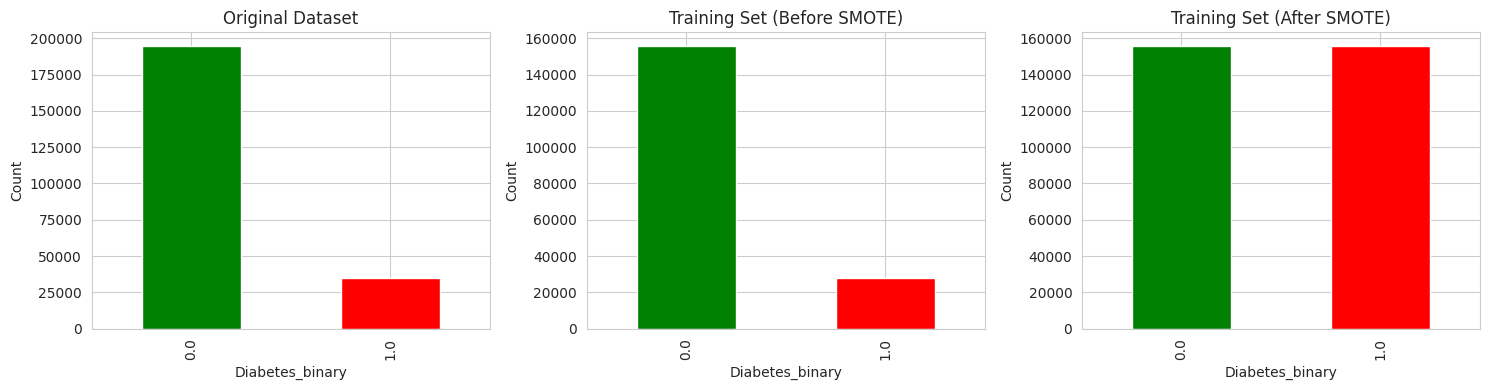

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

y.value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Original Dataset')
axes[0].set_ylabel('Count')

y_train.value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Training Set (Before SMOTE)')
axes[1].set_ylabel('Count')

pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[2], color=['green', 'red'])
axes[2].set_title('Training Set (After SMOTE)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Summary & Data Export

In [22]:
print("=" * 60)
print("PHASE 01 DATA PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\nOriginal dataset shape: {df.shape}")
print(f"Clean dataset shape: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"\nFeatures: {x.shape[1]}")
print(f"Target variable: {target_col}")
print(f"\nClass distribution (original):")
print(y.value_counts())
print(f"\nClass distribution (after SMOTE):")
print(pd.Series(y_train_smote).value_counts())
print(f"\nTraining set: {x_train_smote.shape}")
print(f"Test set: {x_test.shape}")
print("\n" + "=" * 60)

PHASE 01 DATA PREPROCESSING SUMMARY

Original dataset shape: (253680, 22)
Clean dataset shape: (229474, 22)
Rows removed: 24206

Features: 21
Target variable: Diabetes_binary

Class distribution (original):
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64

Class distribution (after SMOTE):
Diabetes_binary
0.0    155501
1.0    155501
Name: count, dtype: int64

Training set: (311002, 21)
Test set: (45895, 21)



In [23]:
# 1. Create Undersampled Balanced Dataset
df_pos = df_clean[df_clean[target_col] == 1]
df_neg = df_clean[df_clean[target_col] == 0]

# Downsample negative class
df_neg_downsampled = df_neg.sample(len(df_pos), random_state=42)

# Combine and shuffle
df_undersampled = pd.concat([df_pos, df_neg_downsampled]).sample(frac=1, random_state=42)

print(f"Undersampled Dataset Shape: {df_undersampled.shape}")
print(f"Class Distribution:\n{df_undersampled[target_col].value_counts()}")

# 2. Train/Test Split (80/20 on balanced data)
X_under = df_undersampled.drop(columns=[target_col])
y_under = df_undersampled[target_col]

# Scale the features
scaler_under = StandardScaler()
X_under_scaled = scaler_under.fit_transform(X_under)

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_under_scaled, y_under, test_size=0.2, random_state=42, stratify=y_under
)

# Convert to DataFrames for consistency with previous functions
X_train_u = pd.DataFrame(X_train_u, columns=X_under.columns)
X_test_u = pd.DataFrame(X_test_u, columns=X_under.columns)

Undersampled Dataset Shape: (70194, 22)
Class Distribution:
Diabetes_binary
1.0    35097
0.0    35097
Name: count, dtype: int64


In [24]:
# Export preprocessed data for Phase 02
x_train_smote.to_csv('x_train_smote.csv', index=False)
x_test.to_csv('x_test.csv', index=False)
pd.Series(y_train_smote).to_csv('y_train_smote.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Preprocessed data exported:")
print("- x_train_smote.csv")
print("- x_test.csv")
print("- y_train_smote.csv")
print("- y_test.csv")

Preprocessed data exported:
- x_train_smote.csv
- x_test.csv
- y_train_smote.csv
- y_test.csv


Calculating PCA...
Calculating t-SNE...
Calculating UMAP...


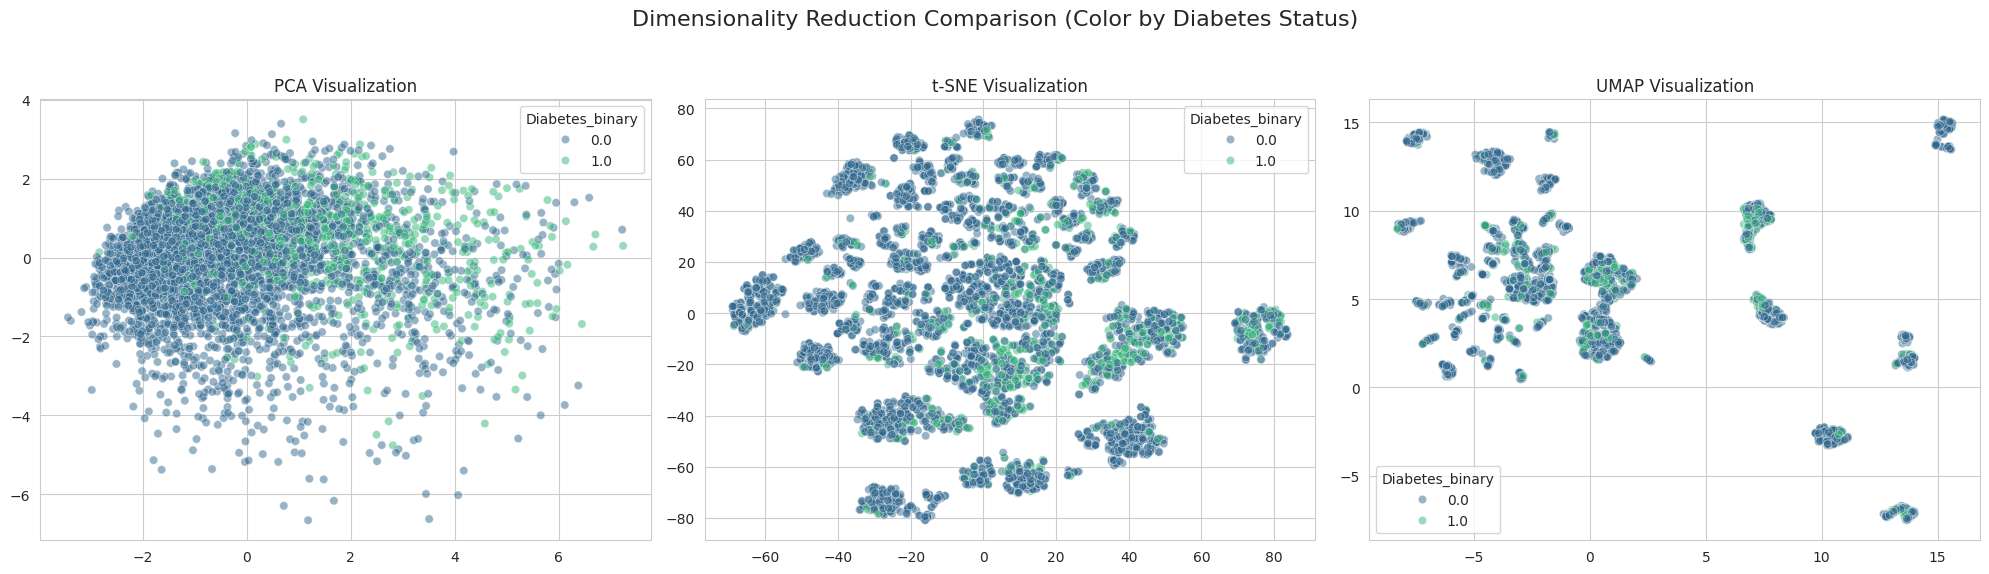

In [25]:
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare a manageable sample (5k rows) for visualization
sample_size = 5000
# Use positional indices to avoid index mismatch errors
indices = np.random.choice(len(df_clean), sample_size, replace=False)

# Access by position using .iloc
x_sample = x_scaled.iloc[indices]
y_sample = df_clean.iloc[indices][target_col]

# 2. Apply Dimensionality Reduction
print("Calculating PCA...")
pca_res = PCA(n_components=2).fit_transform(x_sample)

print("Calculating t-SNE...")
tsne_res = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(x_sample)

print("Calculating UMAP...")
umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(x_sample)

# 3. Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA Plot
sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], hue=y_sample, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('PCA Visualization')

# t-SNE Plot
sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], hue=y_sample, palette='viridis', alpha=0.5, ax=axes[1])
axes[1].set_title('t-SNE Visualization')

# UMAP Plot
sns.scatterplot(x=umap_res[:,0], y=umap_res[:,1], hue=y_sample, palette='viridis', alpha=0.5, ax=axes[2])
axes[2].set_title('UMAP Visualization')

plt.suptitle('Dimensionality Reduction Comparison (Color by Diabetes Status)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [26]:
# Feature Selection: Dropping least correlated/significant features based on user request
drop_cols = ["Fruits", "Veggies", "Sex", "CholCheck", "AnyHealthcare"]
df_model = df_clean.drop(columns=drop_cols)

# Data Splitting
X_raw = df_model.drop("Diabetes_binary", axis=1)
y_raw = df_model["Diabetes_binary"]

# Balancing using NearMiss (Undersampling)
from imblearn.under_sampling import NearMiss
nm = NearMiss(version=1, n_neighbors=10)
X_resampled, y_resampled = nm.fit_resample(X_raw, y_raw)

print(f"Resampled Shape: {X_resampled.shape}")
print(y_resampled.value_counts())

# Split and Scale
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)
scaler_p = StandardScaler()
X_train_p = scaler_p.fit_transform(X_train_p)
X_test_p = scaler_p.transform(X_test_p)

Resampled Shape: (70194, 16)
Diabetes_binary
0.0    35097
1.0    35097
Name: count, dtype: int64


In [27]:
import pandas as pd
import numpy as np

# Create interaction features on the cleaned dataframe
df_eng = df_clean.copy()

# 1. Health-Weight Interaction
df_eng['GenHlth_BMI'] = df_eng['GenHlth'] * df_eng['BMI']

# 2. Age-BloodPressure Interaction
df_eng['Age_HighBP'] = df_eng['Age'] * df_eng['HighBP']

# 3. Physical Health vs Physical Activity
df_eng['PhysHlth_NoActivity'] = df_eng['PhysHlth'] * (1 - df_eng['PhysActivity'])

# Re-scale the entire feature set including new features
scaler_eng = StandardScaler()
x_eng = df_eng.drop(columns=[target_col])
x_eng_scaled = pd.DataFrame(scaler_eng.fit_transform(x_eng), columns=x_eng.columns)

print(f"New feature space shape: {x_eng_scaled.shape}")

New feature space shape: (229474, 24)


Calculating PCA (Engineered)...
Calculating t-SNE (Engineered)...
Calculating UMAP (Engineered)...


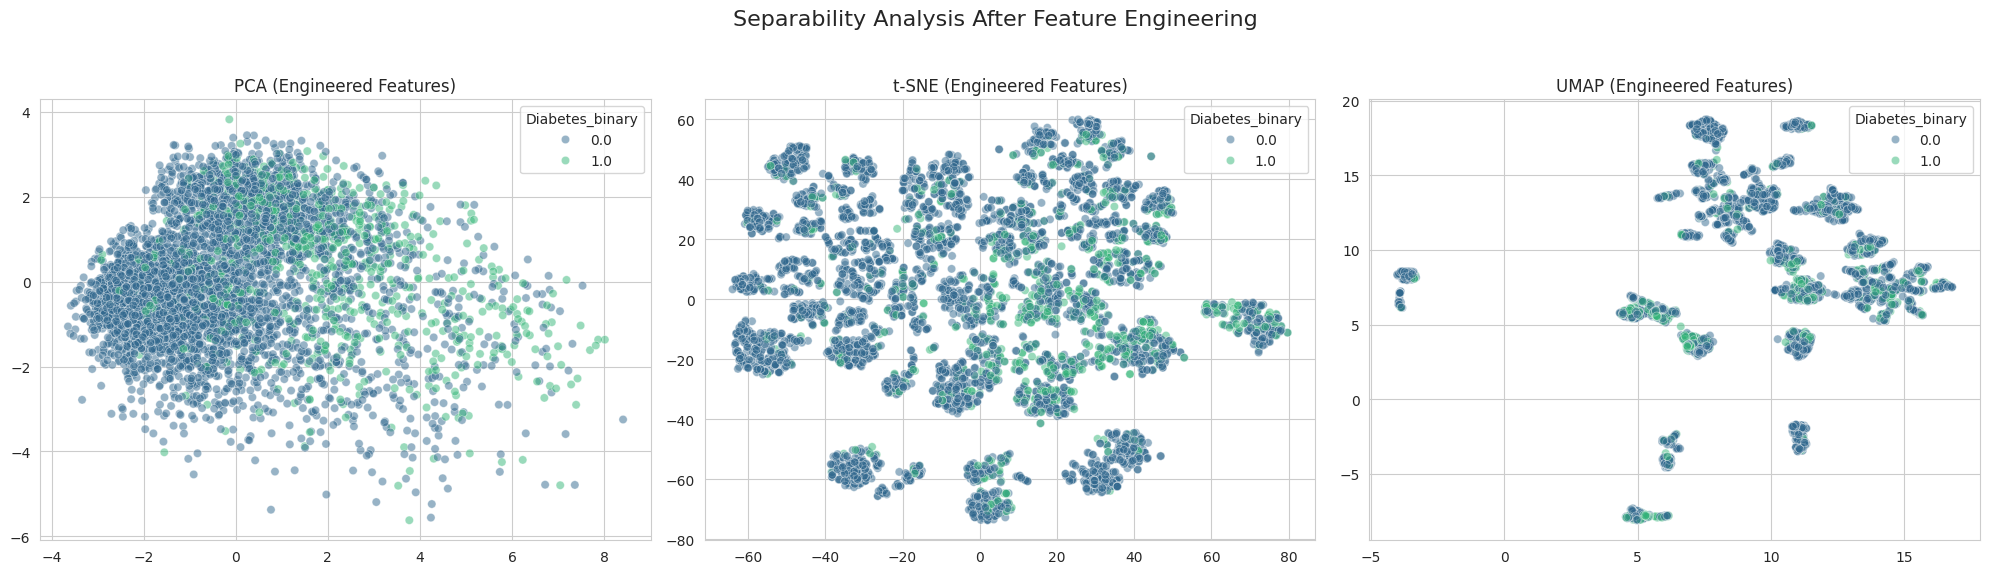

In [28]:
# Re-run dimensionality reduction on a sample of the engineered features
sample_size_eng = 5000
indices_eng = np.random.choice(len(df_eng), sample_size_eng, replace=False)

x_sample_eng = x_eng_scaled.iloc[indices_eng]
y_sample_eng = df_eng.iloc[indices_eng][target_col]

print("Calculating PCA (Engineered)...")
pca_eng = PCA(n_components=2).fit_transform(x_sample_eng)

print("Calculating t-SNE (Engineered)...")
tsne_eng = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(x_sample_eng)

print("Calculating UMAP (Engineered)...")
umap_eng = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(x_sample_eng)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.scatterplot(x=pca_eng[:,0], y=pca_eng[:,1], hue=y_sample_eng, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('PCA (Engineered Features)')
sns.scatterplot(x=tsne_eng[:,0], y=tsne_eng[:,1], hue=y_sample_eng, palette='viridis', alpha=0.5, ax=axes[1])
axes[1].set_title('t-SNE (Engineered Features)')
sns.scatterplot(x=umap_eng[:,0], y=umap_eng[:,1], hue=y_sample_eng, palette='viridis', alpha=0.5, ax=axes[2])
axes[2].set_title('UMAP (Engineered Features)')
plt.suptitle('Separability Analysis After Feature Engineering', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Correlation of Engineered Features with Target:
GenHlth_BMI            0.322278
Age_HighBP             0.260767
PhysHlth_NoActivity    0.133108
Name: Diabetes_binary, dtype: float64


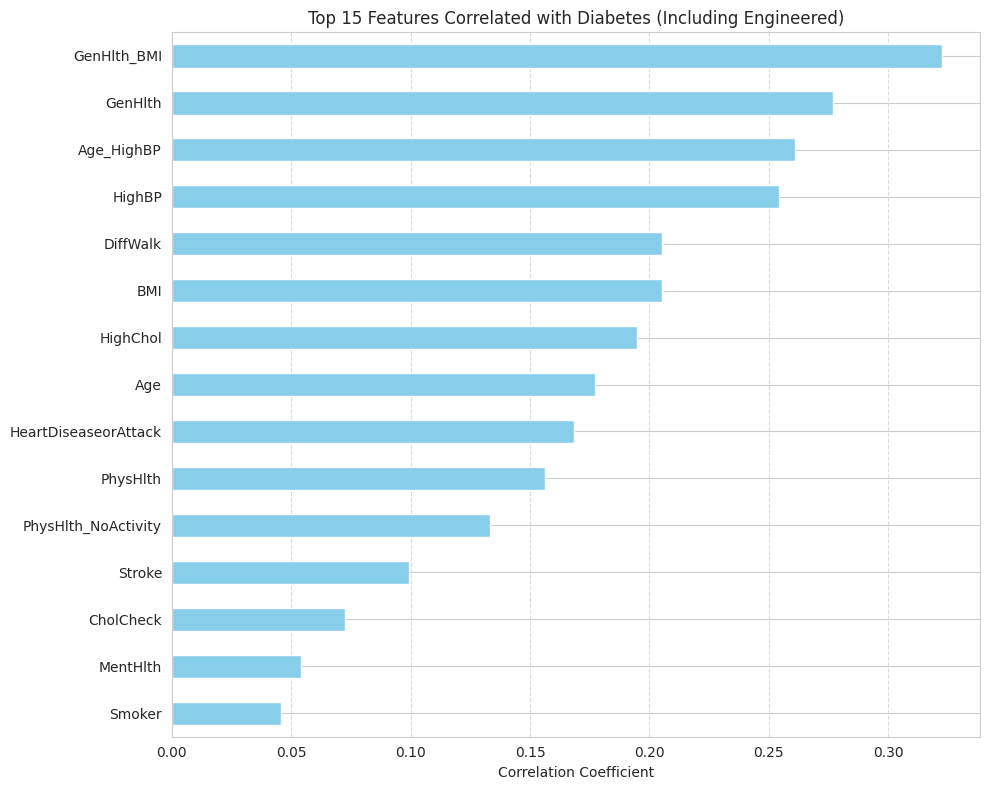

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation with target for the engineered features
eng_corr = df_eng.corr()[target_col].sort_values(ascending=False)

# Select the newly created features specifically to see their impact
new_features = ['GenHlth_BMI', 'Age_HighBP', 'PhysHlth_NoActivity']
print("Correlation of Engineered Features with Target:")
print(eng_corr[new_features])

# Plot top correlations including engineered ones
plt.figure(figsize=(10, 8))
eng_corr.drop(target_col).sort_values(ascending=True).tail(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Features Correlated with Diabetes (Including Engineered)')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Advanced Deep Learning Architectures
In this section, we transition from traditional ML models to deep learning. We will implement a 1D Convolutional Neural Network (Conv1D) and a Variational Autoencoder (VAE) to capture complex, non-linear relationships and local feature dependencies.

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# Reshape data for Conv1D: (batch, steps, channels)
# We use the NearMiss balanced data prepared earlier
X_train_dl = X_train_p.reshape((X_train_p.shape[0], X_train_p.shape[1], 1))
X_test_dl = X_test_p.reshape((X_test_p.shape[0], X_test_p.shape[1], 1))

print(f"Original training shape: {X_train_p.shape}")
print(f"Reshaped DL input shape: {X_train_dl.shape}")

Original training shape: (49135, 16)
Reshaped DL input shape: (49135, 16, 1)



==================== Logistic Regression ====================
Training score: 0.8511
Test score: 0.8471
RMSE: 0.3910

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.92      0.86     10468
         1.0       0.91      0.77      0.84     10591

    accuracy                           0.85     21059
   macro avg       0.86      0.85      0.85     21059
weighted avg       0.86      0.85      0.85     21059



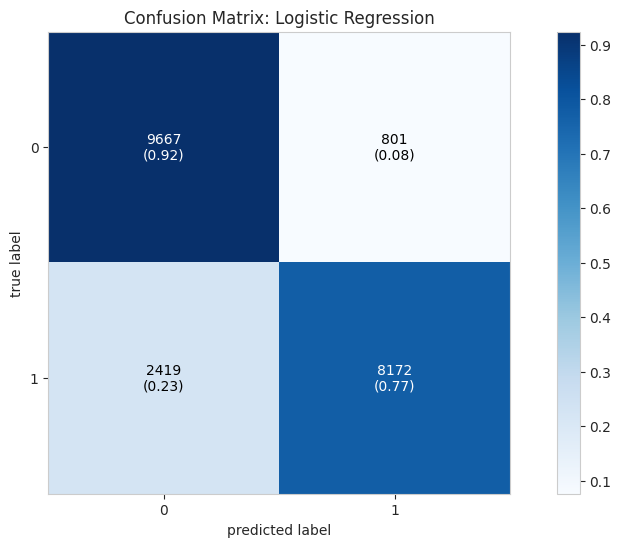


==================== Decision Tree ====================
Training score: 0.8657
Test score: 0.8476
RMSE: 0.3904

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.96      0.86     10468
         1.0       0.95      0.74      0.83     10591

    accuracy                           0.85     21059
   macro avg       0.87      0.85      0.85     21059
weighted avg       0.87      0.85      0.85     21059



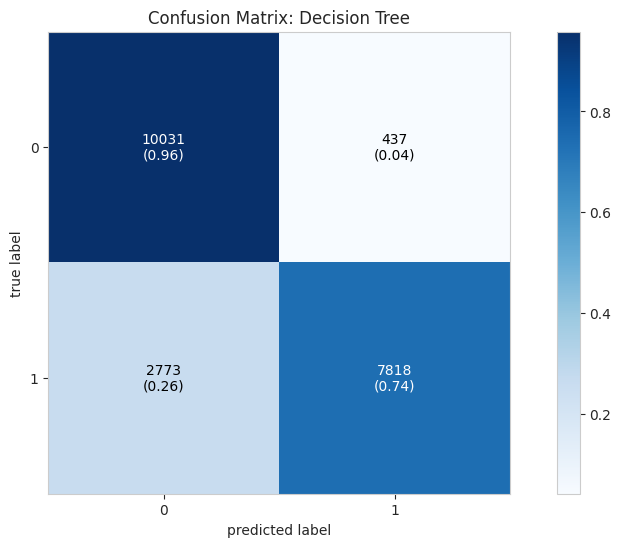


==================== Random Forest ====================
Training score: 0.8713
Test score: 0.8589
RMSE: 0.3757

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.95      0.87     10468
         1.0       0.94      0.77      0.85     10591

    accuracy                           0.86     21059
   macro avg       0.87      0.86      0.86     21059
weighted avg       0.87      0.86      0.86     21059



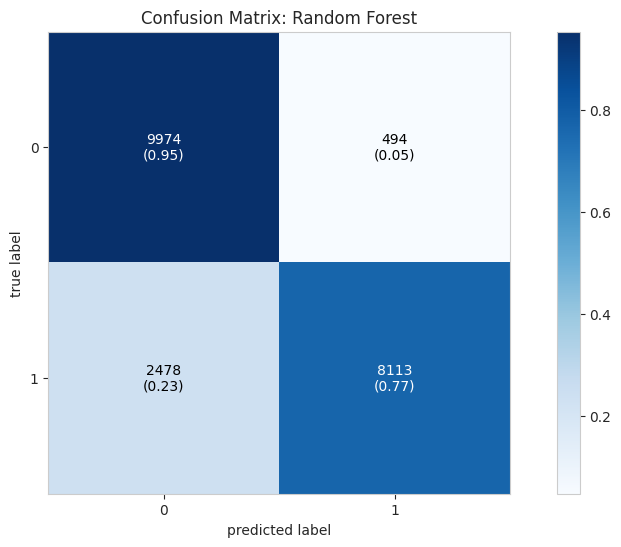


==================== XGBoost ====================
Training score: 0.8769
Test score: 0.8659
RMSE: 0.3662

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.94      0.88     10468
         1.0       0.94      0.79      0.86     10591

    accuracy                           0.87     21059
   macro avg       0.88      0.87      0.87     21059
weighted avg       0.88      0.87      0.87     21059



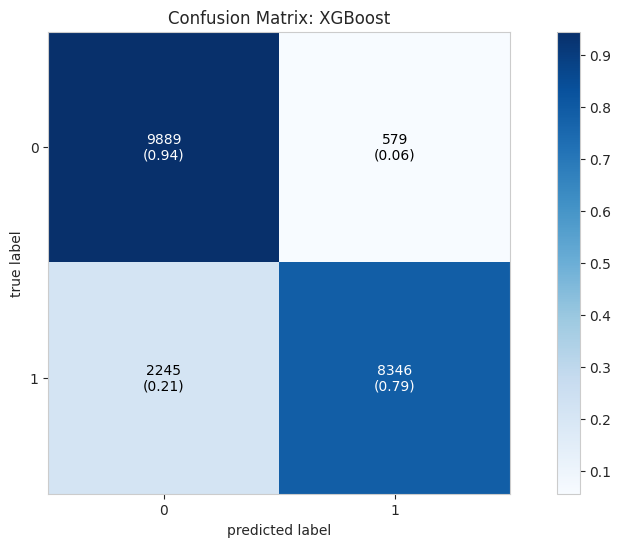

In [34]:
from sklearn.ensemble import RandomForestClassifier

def evaluate_model(model, name):
    model.fit(X_train_p, y_train_p)
    preds = model.predict(X_test_p)

    print(f"\n{'='*20} {name} {'='*20}")
    print(f'Training score: {model.score(X_train_p, y_train_p):.4f}')
    print(f'Test score: {model.score(X_test_p, y_test_p):.4f}')

    mse = mean_squared_error(y_test_p, preds)
    print(f'RMSE: {math.sqrt(mse):.4f}')

    print("\nClassification Report:")
    print(classification_report(y_test_p, preds))

    cm = confusion_matrix(y_test_p, preds)
    plot_confusion_matrix(conf_mat=cm, show_absolute=True, show_normed=True, colorbar=True)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# List of models to run
models_to_run = [
    (LogisticRegression(max_iter=1500), "Logistic Regression"),
    (DecisionTreeClassifier(max_depth=12), "Decision Tree"),
    (RandomForestClassifier(max_depth=12, n_estimators=10, random_state=42), "Random Forest"),
    (XGBClassifier(eval_metric='error', learning_rate=0.1), "XGBoost")
]

for model, name in models_to_run:
    evaluate_model(model, name)

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Reconstruct DataFrames from resampled data to add features
# X_resampled (from cell adfeb8ea) contains the features for the NearMiss balanced set
X_res_df = X_resampled.copy()

# 2. Add Engineered Features
X_res_df['GenHlth_BMI'] = X_res_df['GenHlth'] * X_res_df['BMI']
X_res_df['Age_HighBP'] = X_res_df['Age'] * X_res_df['HighBP']
X_res_df['PhysHlth_NoActivity'] = X_res_df['PhysHlth'] * (1 - X_res_df['PhysActivity'])

# 3. Split and Re-Scale
X_train_p_raw, X_test_p_raw, y_train_p, y_test_p = train_test_split(
    X_res_df, y_resampled, test_size=0.3, random_state=42
)

scaler_p = StandardScaler()
X_train_p = scaler_p.fit_transform(X_train_p_raw)
X_test_p = scaler_p.transform(X_test_p_raw)

print(f"Updated X_train_p shape: {X_train_p.shape}")
print("Engineered features added and data re-scaled.")

Updated X_train_p shape: (49135, 19)
Engineered features added and data re-scaled.



==================== Logistic Regression ====================
Training score: 0.8507
Test score: 0.8470
RMSE: 0.3912

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.92      0.86     10468
         1.0       0.91      0.77      0.84     10591

    accuracy                           0.85     21059
   macro avg       0.86      0.85      0.85     21059
weighted avg       0.86      0.85      0.85     21059



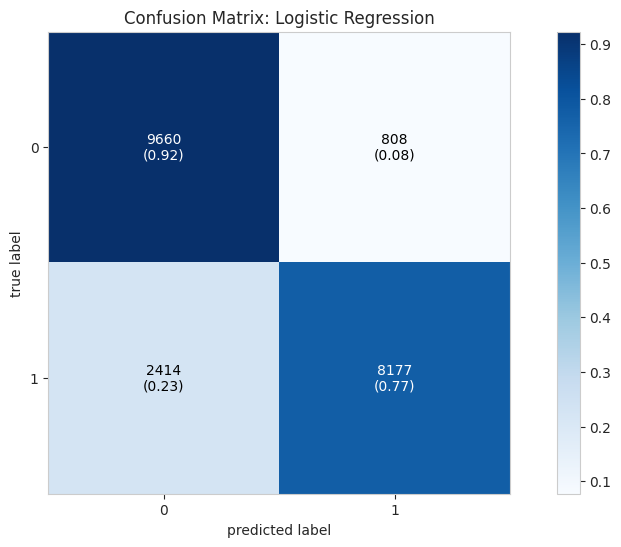


==================== Decision Tree ====================
Training score: 0.8681
Test score: 0.8470
RMSE: 0.3911

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.96      0.86     10468
         1.0       0.95      0.73      0.83     10591

    accuracy                           0.85     21059
   macro avg       0.87      0.85      0.85     21059
weighted avg       0.87      0.85      0.85     21059



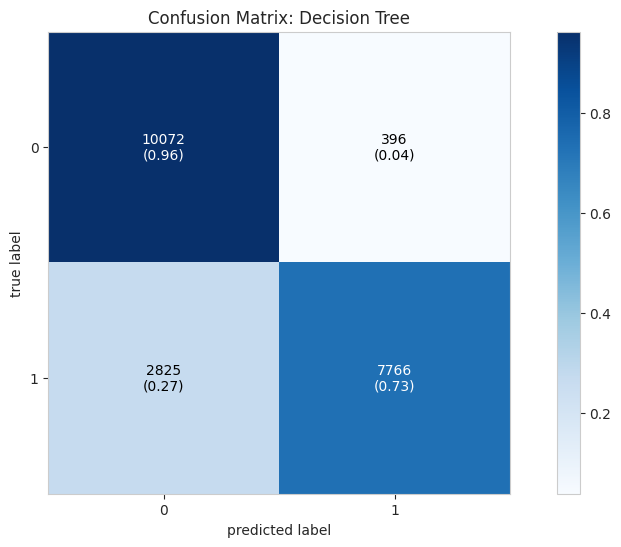


==================== Random Forest ====================
Training score: 0.8700
Test score: 0.8569
RMSE: 0.3783

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.95      0.87     10468
         1.0       0.94      0.76      0.84     10591

    accuracy                           0.86     21059
   macro avg       0.87      0.86      0.86     21059
weighted avg       0.87      0.86      0.86     21059



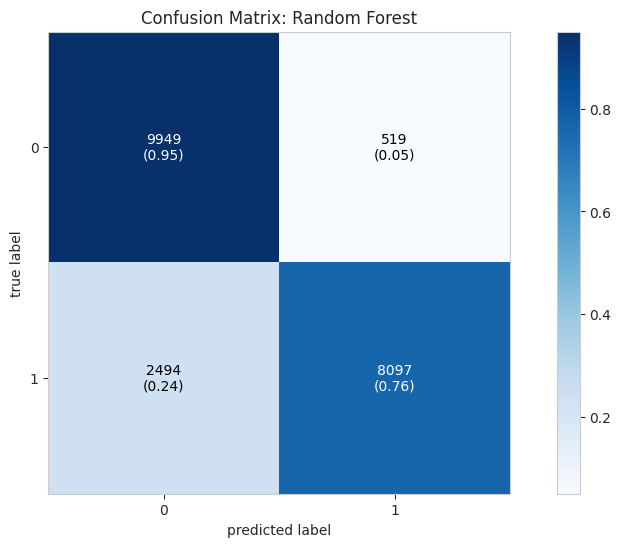


==================== XGBoost ====================
Training score: 0.8773
Test score: 0.8643
RMSE: 0.3684

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.95      0.87     10468
         1.0       0.94      0.78      0.85     10591

    accuracy                           0.86     21059
   macro avg       0.87      0.86      0.86     21059
weighted avg       0.87      0.86      0.86     21059



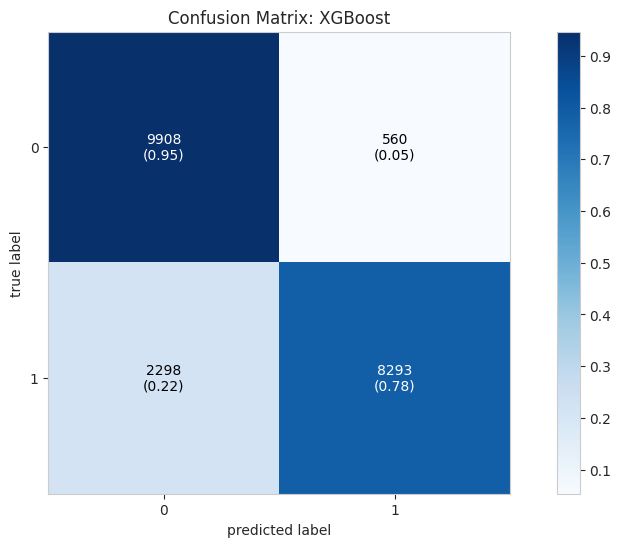

In [36]:
# Re-run the models with the updated X_train_p and X_test_p
from sklearn.ensemble import RandomForestClassifier

for model, name in models_to_run:
    evaluate_model(model, name)

In [37]:
pip install opendatasets

## Load Data

In [38]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kyrillosheniensadak
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:20<00:00, 121MB/s]


## Import Libs

In [39]:
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import shutil
import random

## Preprocessing

In [40]:
base_dir = '/content/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [41]:
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        counts[cls] = len(os.listdir(os.path.join(folder, cls)))
    return counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)
val_counts = count_images(val_dir)

print("Train:", train_counts)
print("Test:", test_counts)
print("Validation:", val_counts)

Train: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Test: {'PNEUMONIA': 390, 'NORMAL': 234}
Validation: {'PNEUMONIA': 8, 'NORMAL': 8}


In [42]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [43]:
test_val_datagen = ImageDataGenerator(rescale=1./255)

In [44]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 5216 images belonging to 2 classes.


In [45]:
validation_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 16 images belonging to 2 classes.


In [46]:
test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [47]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## CNN

In [48]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                        ReduceLROnPlateau, CSVLogger)
from tensorflow.keras.metrics import Recall, Precision, AUC
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
def build_densenet_model(input_shape=(224, 224, 3), dropout_rate=0.5):
    """
    DenseNet121 backbone with a custom classification head.
    DenseNet121 is preferred for medical imaging — its dense
    connections encourage feature reuse and produce strong
    gradient flow, which helps on small datasets.
    """
    backbone = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    backbone.trainable = False

    x = backbone.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout_rate / 2)(x)
    output = Dense(1, activation='sigmoid')(x)   # binary: NORMAL vs PNEUMONIA

    model = Model(inputs=backbone.input, outputs=output)
    return model, backbone

In [50]:
model, backbone = build_densenet_model()
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,337,025 (27.99 MB)

 Trainable params: 297,473 (1.13 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [51]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)

In [ ]:
os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    # Save the best model by validation recall 
    ModelCheckpoint(
        filepath='checkpoints/best_model_recall.keras',
        monitor='val_recall',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='checkpoints/best_model_auc.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_recall',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger('training_log.csv', append=True)
]

## Training

In [ ]:
print("\n" + "="*60)
print("PHASE 1: Training classification head (backbone frozen)")
print("="*60)

history_phase1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    class_weight=class_weights_dict,   # from your preprocessing step
    callbacks=callbacks,
    verbose=1
)


PHASE 1: Training classification head (backbone frozen)
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.8568 - auc: 0.9352 - loss: 0.3100 - precision: 0.9605 - recall: 0.8404
Epoch 1: val_recall improved from None to 0.75000, saving model to checkpoints/best_model_recall.keras

Epoch 1: finished saving model to checkpoints/best_model_recall.keras

Epoch 1: val_auc improved from None to 1.00000, saving model to checkpoints/best_model_auc.keras

Epoch 1: finished saving model to checkpoints/best_model_auc.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 190s 788ms/step - accuracy: 0.8980 - auc: 0.9640 - loss: 0.2411 - precision: 0.9718 - recall: 0.8885 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2400 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.9238 - auc: 0.9803 - loss: 0.1775 - precision: 0.9783 - recall: 0.9180
Epoch 2: val_recall did not improve from 0.75000

Epoch 2: val_auc

## Testing

In [55]:
print("\n" + "="*60)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*60)

best_model = tf.keras.models.load_model('checkpoints/best_model_recall.keras')
test_results = best_model.evaluate(test_generator, verbose=1)

metric_names = ['Loss', 'Accuracy', 'Recall', 'Precision', 'AUC']
for name, val in zip(metric_names, test_results):
    print(f"  {name:<12}: {val:.4f}")


FINAL EVALUATION ON HELD-OUT TEST SET
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 898ms/step - accuracy: 0.8734 - auc: 0.9529 - loss: 0.2713 - precision: 0.9103 - recall: 0.8846
  Loss        : 0.2713
  Accuracy    : 0.8734
  Recall      : 0.8846
  Precision   : 0.9103
  AUC         : 0.9529


## Metrics

In [56]:
print("\n" + "="*60)
print("THRESHOLD ANALYSIS (maximise recall for healthcare safety)")
print("="*60)

y_true = test_generator.classes
y_pred_proba = best_model.predict(test_generator, verbose=0).ravel()

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

thresholds = np.arange(0.2, 0.8, 0.05)
results = []
for t in thresholds:
    y_pred = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall    = tp / (tp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    f1        = 2 * recall * precision / (recall + precision + 1e-9)
    results.append({'threshold': t, 'recall': recall,
                    'precision': precision, 'f1': f1})
    print(f"  Threshold={t:.2f} | Recall={recall:.3f} | "
          f"Precision={precision:.3f} | F1={f1:.3f}")

# Pick the threshold that keeps recall ≥ 0.95
clinical_threshold = next(
    (r['threshold'] for r in results if r['recall'] >= 0.95), 0.3
)
print(f"\n  ✅ Recommended clinical threshold: {clinical_threshold:.2f}")

# Final report at the chosen threshold
y_pred_final = (y_pred_proba >= clinical_threshold).astype(int)
class_names = list(test_generator.class_indices.keys())
print("\n" + classification_report(y_true, y_pred_final,
                                   target_names=class_names))
print(f"  ROC-AUC: {roc_auc_score(y_true, y_pred_proba):.4f}")


THRESHOLD ANALYSIS (maximise recall for healthcare safety)
  Threshold=0.20 | Recall=0.969 | Precision=0.822 | F1=0.889
  Threshold=0.25 | Recall=0.956 | Precision=0.836 | F1=0.892
  Threshold=0.30 | Recall=0.941 | Precision=0.862 | F1=0.900
  Threshold=0.35 | Recall=0.923 | Precision=0.876 | F1=0.899
  Threshold=0.40 | Recall=0.910 | Precision=0.890 | F1=0.900
  Threshold=0.45 | Recall=0.895 | Precision=0.902 | F1=0.898
  Threshold=0.50 | Recall=0.885 | Precision=0.910 | F1=0.897
  Threshold=0.55 | Recall=0.877 | Precision=0.927 | F1=0.901
  Threshold=0.60 | Recall=0.856 | Precision=0.946 | F1=0.899
  Threshold=0.65 | Recall=0.841 | Precision=0.956 | F1=0.895
  Threshold=0.70 | Recall=0.810 | Precision=0.958 | F1=0.878
  Threshold=0.75 | Recall=0.779 | Precision=0.962 | F1=0.861
  Threshold=0.80 | Recall=0.741 | Precision=0.973 | F1=0.841

  ✅ Recommended clinical threshold: 0.20

              precision    recall  f1-score   support

      NORMAL       0.93      0.65      0.76      

## Visualizing

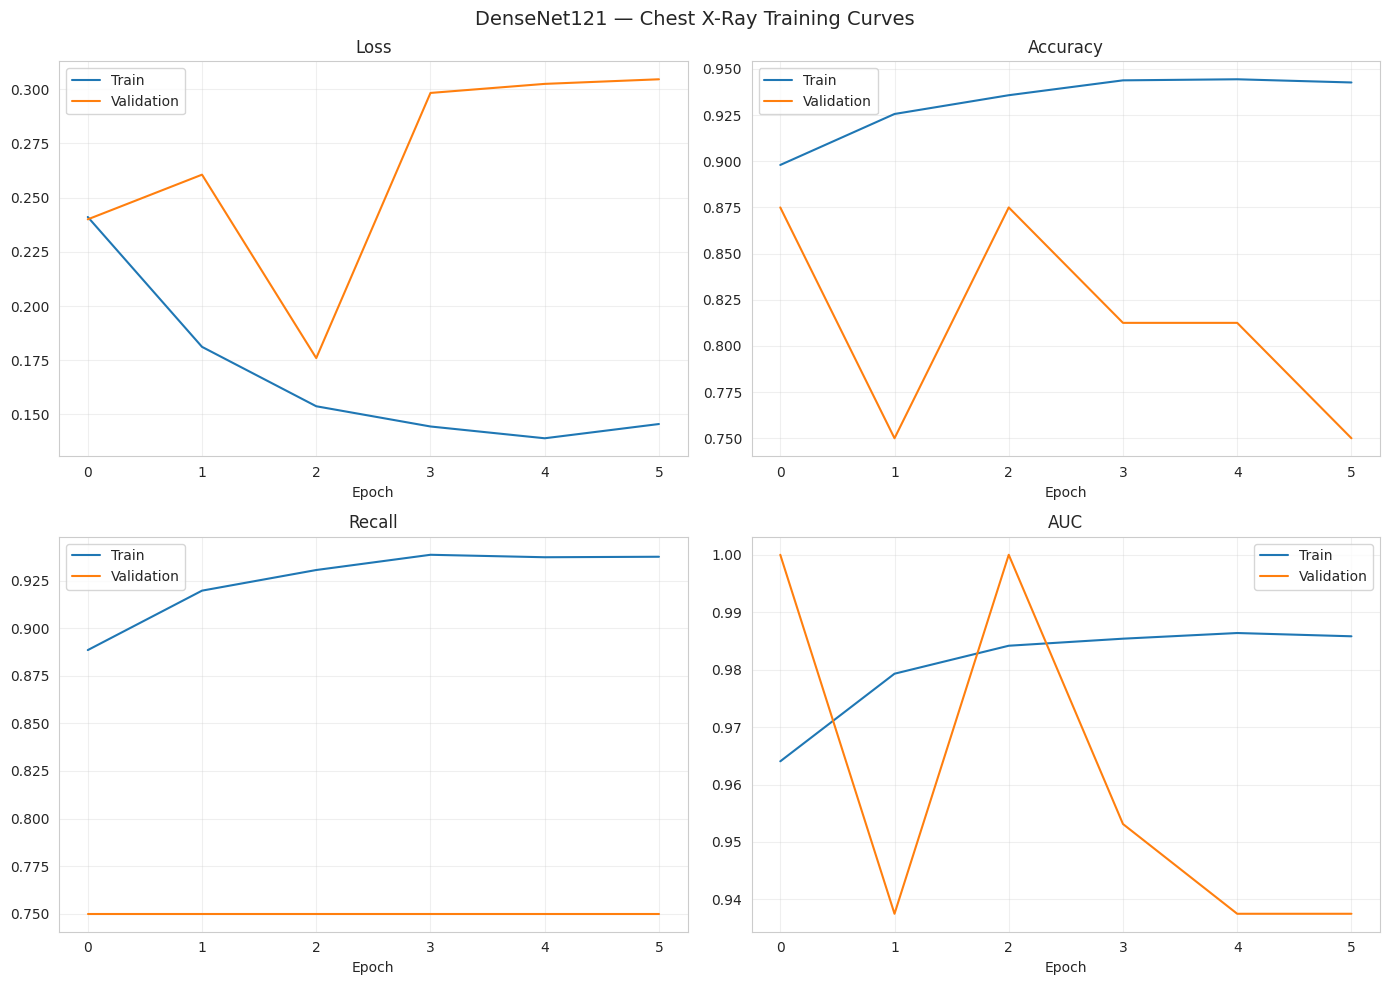

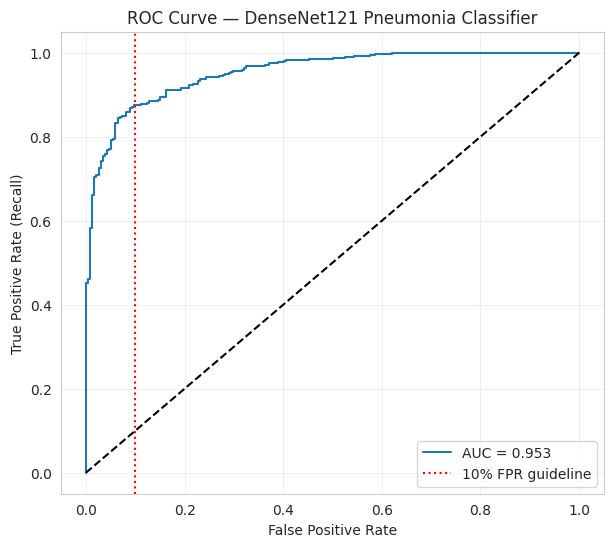


✅ Phase 03 complete. Best model saved to checkpoints/


In [59]:
history = history_phase1.history
epochs_range = range(len(history['loss']))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DenseNet121 — Chest X-Ray Training Curves', fontsize=14)

phase1_end = len(history_phase1.history['loss'])

pairs = [
    ('loss',      'val_loss',      'Loss',      axes[0, 0]),
    ('accuracy',  'val_accuracy',  'Accuracy',  axes[0, 1]),
    ('recall',    'val_recall',    'Recall',    axes[1, 0]),
    ('auc',       'val_auc',       'AUC',       axes[1, 1]),
]

for train_key, val_key, title, ax in pairs:
    ax.plot(epochs_range, history[train_key],    label='Train')
    ax.plot(epochs_range, history[val_key],      label='Validation')
    # ax.axvline(phase1_end - 1, color='gray',
    #            linestyle='--', label='Fine-tune start') # Commented out as there's only one phase history currently
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.axvline(x=0.1, color='r', linestyle=':', label='10% FPR guideline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — DenseNet121 Pneumonia Classifier')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print("\n✅ Phase 03 complete. Best model saved to checkpoints/")